# 11 · A race distance of energy — capstone

A modern hybrid race car spends two currencies. **Fuel** only ever goes down: it is burned, and the
car gets lighter for it. **Charge** goes both ways: the car can only deploy what it has already put
back into the battery, minus the losses of the round trip. This notebook runs the reference 2026-style
F1 hybrid over a **full 66-lap race distance** at Catalunya and follows both currencies lap by lap,
with nothing hand-waved — every joule deployed was harvested first, every kilogram burned came off
the car's mass, and the pace responds to both.

What follows:

1. **The race** — 66 laps on the quasi-steady tier, carrying the pack and the fuel load across every
   start/finish line.
2. **State of charge, both directions** — the pack drains under deployment and refills under braking
   and on the straights, bounded by its usable window and by a per-lap harvest budget.
3. **The ledger** — energy deployed and harvested per lap, and which limit actually binds.
4. **Fuel burn and pace** — the car gets lighter and faster; and, honestly, the declared race fuel
   load does not cover the distance at this engine's modelled consumption.
5. **Where the energy moves inside a lap** — deployment, braking recovery, and the on-throttle
   recharge phases resolved along the lap.
6. **The overtake button** — one lap with the extra-deployment mode enabled, measured rather than
   advertised.
7. **A transient cross-check** — the same energy manager driving the time-domain tier.
8. **Pitch under braking** — the 14-DOF tier's platform moving, and what that does to the
   aerodynamic balance.

Theory pages: [`ers-energy-manager.md`](../docs/theory/ers-energy-manager.md) ·
[`fuel-mass.md`](../docs/theory/fuel-mass.md) ·
[`qss-powertrain.md`](../docs/theory/qss-powertrain.md) ·
[`t3-chassis.md`](../docs/theory/t3-chassis.md)

In [1]:
import time
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pyarrow.parquet as pq
import yaml
from matplotlib.colors import LinearSegmentedColormap


def _find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data").is_dir() and (p / "crates").is_dir():
            return p
    raise RuntimeError("run this notebook from inside the outlap repository")


ROOT = _find_root(Path.cwd())

# Solver pin: a coarse g-g-g-v envelope grid. Each distinct vehicle/mode combination compiles its own
# envelope (the cold assembly step) and this notebook touches several, so they all run coarse. The
# production default (40x25x7) is what `solve_lap_dataset(...)` gives with no `sim=` argument; it
# moves lap times by well under a tenth here and costs a lot more to build.
COARSE = {"envelope": {"v_points": 8, "ax_points": 7, "g_normal_points": 2}}

# Validated reference palette (light mode) — same style as the rest of the tour.
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e7e6e2"
BLUE, AQUA, RED = "#2a78d6", "#1baf7a", "#e34948"
LOADS5 = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#0d366b"]  # ordinal, 5 steps
SEQ = LinearSegmentedColormap.from_list(
    "outlap_blue",
    ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"],
)

mpl.rcParams.update(
    {
        "figure.dpi": 115, "figure.facecolor": "white", "axes.facecolor": "white",
        "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlecolor": INK,
        "axes.titlesize": 12, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
        "axes.spines.top": False, "axes.spines.right": False,
        "xtick.color": INK2, "ytick.color": INK2, "font.size": 10.5,
        "legend.frameon": False, "lines.linewidth": 2.0,
    }
)

from outlap.core import Track, min_curvature, solve_lap_dataset, solve_stint_dataset

F1 = ROOT / "data" / "vehicles" / "f1_2026"
catalunya = Track.load(str(ROOT / "data" / "tracks" / "catalunya_osm"))
raceline = min_curvature(catalunya, half_width_m=1.1)
LAPS = 66  # the Spanish Grand Prix distance

# Every budget quoted in this notebook is read back from the car's own files — the same files the
# solver reads — so nothing below is a magic number typed into a plot.
spec = yaml.safe_load((F1 / "vehicle.yaml").read_text())
pack = yaml.safe_load((F1 / spec["batteries"]["f1_es"]["params"]).read_text())
SOC_LO, SOC_HI = pack["soc_window"]
E_PACK_MJ = pack["capacity"]["e_pack_wh"] * 3.6e-3          # total store, MJ
E_WINDOW_MJ = E_PACK_MJ * (SOC_HI - SOC_LO)                 # usable on-track energy, MJ
HARVEST_BUDGET_MJ = spec["policy"]["recovery"]["per_lap_harvest_mj"]
DEPLOY_CAP_KW = spec["policy"]["deployment"]["power_limit_kw"]
FUEL_START_KG = spec["fuel"]["initial_kg"]
TANK_KG = spec["fuel"]["tank_kg"]
H_STATIC_F_MM = spec["suspension"]["front"]["static_ride_height_m"] * 1e3
H_STATIC_R_MM = spec["suspension"]["rear"]["static_ride_height_m"] * 1e3

WALL: dict[str, float] = {}   # solver wall clock per stage, printed at the end
t_notebook = time.perf_counter()

print(f"{spec['name']} — {LAPS} laps of Catalunya, on the minimum-curvature line")
print(f"  store       {E_PACK_MJ:.2f} MJ total, usable window {SOC_LO:.0%}-{SOC_HI:.0%} "
      f"= {E_WINDOW_MJ:.2f} MJ on track")
print(f"  deployment  {DEPLOY_CAP_KW:.0f} kW cap, tapered with speed")
print(f"  harvest     {HARVEST_BUDGET_MJ:.1f} MJ per lap allowed back into the store")
print(f"  fuel        {FUEL_START_KG:.0f} kg race load in a {TANK_KG:.0f} kg tank")

Reference F1 2026 hybrid — 66 laps of Catalunya, on the minimum-curvature line
  store       5.71 MJ total, usable window 20%-90% = 4.00 MJ on track
  deployment  350 kW cap, tapered with speed
  harvest     8.5 MJ per lap allowed back into the store
  fuel        80 kg race load in a 110 kg tank


## 1 · The race: 66 laps, carrying state

The quasi-steady tier solves a velocity profile for a lap and then **marches the slow states along
it**: the battery's state of charge, its internal RC voltages and temperature, the machine's winding
temperature, and the fuel mass. Those states carry over the start/finish line — only the per-lap
energy ledger resets, because the regulations budget harvesting *per lap*. So what follows is one
continuous race, not 66 copies of a lap.

**Tyre thermal state is deliberately left out of this run.** This notebook is about energy, and
holding the tyres out of the loop makes the pace progression a clean read on the fuel effect alone:
the car gets lighter, so it gets faster, with nothing else moving underneath it. Tyre warm-up, wear,
the grip cliff and the pace they take away are the entire subject of
[10 · stint strategy](10_stint_strategy.ipynb) — read the two notebooks together and you have both
halves of a race: the tyres taking pace away while the fuel load gives it back. (The tyre march also
costs several times as much per lap as everything else in the loop put together, which is why a race
distance is affordable here and a long stint is not.)

The pack is seeded mid-window, at 55% state of charge — a declared starting assumption, not a
measurement — and the tank starts at the car's declared race fuel load.

In [2]:
t0 = time.perf_counter()
race = solve_stint_dataset(
    str(F1), raceline, n_laps=LAPS, tier="t0", sim=COARSE, tire_thermal=False
)
WALL["the 66-lap race"] = time.perf_counter() - t0
print(f"{LAPS} laps solved in {WALL['the 66-lap race']:.1f} s "
      f"({WALL['the 66-lap race'] / LAPS:.2f} s per lap)")
print(f"resolved vehicle {race.attrs['resolved_hash'][:12]}…, tier {race.attrs['tier']}")
print("per-lap channels:", ", ".join(sorted(race.data_vars)))

laps = race.lap.values
s_m = race.s.values
lap_time = race.lap_time_s.values
soc = race.state_of_charge.values          # (lap, station)
fuel = race.fuel_mass_kg.values            # (lap, station)
deploy_mj = race.deploy_energy_mj.values   # (lap,)
harvest_mj = race.harvest_energy_mj.values  # (lap,)

print(f"\nrace distance   {LAPS * s_m[-1] / 1e3:.1f} km")
print(f"race time       {lap_time.sum() / 60:.2f} min "
      f"(lap 1 {lap_time[0]:.3f} s, fastest {lap_time.min():.3f} s on lap "
      f"{int(laps[lap_time.argmin()])}, last {lap_time[-1]:.3f} s)")
print(f"fuel burned     {fuel[0, 0] - fuel[-1, -1]:.2f} kg — the whole declared load, which turns "
      f"out to matter")
print(f"state of charge {soc.min():.1%} … {soc.max():.1%} (usable window "
      f"{SOC_LO:.0%}-{SOC_HI:.0%})")
print(f"energy deployed {deploy_mj.sum():.1f} MJ over the race "
      f"({deploy_mj.mean():.2f} MJ per lap)")
print(f"energy harvested {harvest_mj.sum():.1f} MJ over the race "
      f"({harvest_mj.mean():.2f} MJ per lap)")
print(f"winding temperature {race.machine_temp_c.values.min():.0f}…"
      f"{race.machine_temp_c.values.max():.0f} °C, "
      f"pack {race.pack_temp_c.values.min():.0f}…{race.pack_temp_c.values.max():.0f} °C")

# Self-checks: the race is only meaningful if the accounting closed.
assert race.attrs["n_laps"] == LAPS and race.attrs["tier"] == "t0"
assert soc.min() >= SOC_LO - 1e-9, "the pack never discharges below its usable window"
assert soc.max() <= SOC_HI + 1e-9, "the pack never charges above its usable window"
assert (deploy_mj > 0.0).all(), "the car deploys on every lap"
assert (harvest_mj > 0.0).all(), "the car harvests on every lap"
assert (np.diff(fuel.reshape(-1)) <= 1e-9).all(), "fuel mass never increases, ever"

66 laps solved in 136.4 s (2.07 s per lap)
resolved vehicle f7e512f4459b…, tier t0
per-lap channels: deploy_energy_mj, fuel_mass_kg, harvest_energy_mj, lap_time_s, machine_temp_c, pack_temp_c, soc_max, soc_min, state_of_charge, v

race distance   316.3 km
race time       107.30 min (lap 1 98.966 s, fastest 96.702 s on lap 58, last 96.702 s)
fuel burned     80.00 kg — the whole declared load, which turns out to matter
state of charge 20.0% … 90.0% (usable window 20%-90%)
energy deployed 534.9 MJ over the race (8.10 MJ per lap)
energy harvested 561.0 MJ over the race (8.50 MJ per lap)
winding temperature 167…171 °C, pack 51…53 °C


## 2 · State of charge, in both directions

The store is small and the flow through it is large. Below, the left panel is the whole race: for
each lap, the band spans the lowest and highest state of charge reached **on track**, with the
lap-start value drawn through it. The right panel opens up one representative mid-race lap, with the
sections where charge is *going back in* drawn in green.

What to look for:

- From the first laps the band spans most of the usable window: the pack is emptied to its floor and
  refilled to within ten or fifteen points of its ceiling, every lap. The energy manager is not
  hoarding — it deploys greedily whenever the driver asks for drive, and recharges whenever the car is
  braking or the engine has power to spare. The band can never be wider than the regulations' on-track
  swing limit, which for this car is sized to exactly the same energy as its usable pack window.
- Lap 1 is the odd one out: the car starts mid-window with charge it never had to earn, so it can
  spend more than it recovers. From lap 2 onwards the pack starts each lap at the bottom of its
  window and the race becomes a strict earn-then-spend cycle.
- Within a lap the trace is a sawtooth, not a slope. Roughly half the lap distance puts energy back
  in — that is the whole point of a hybrid.

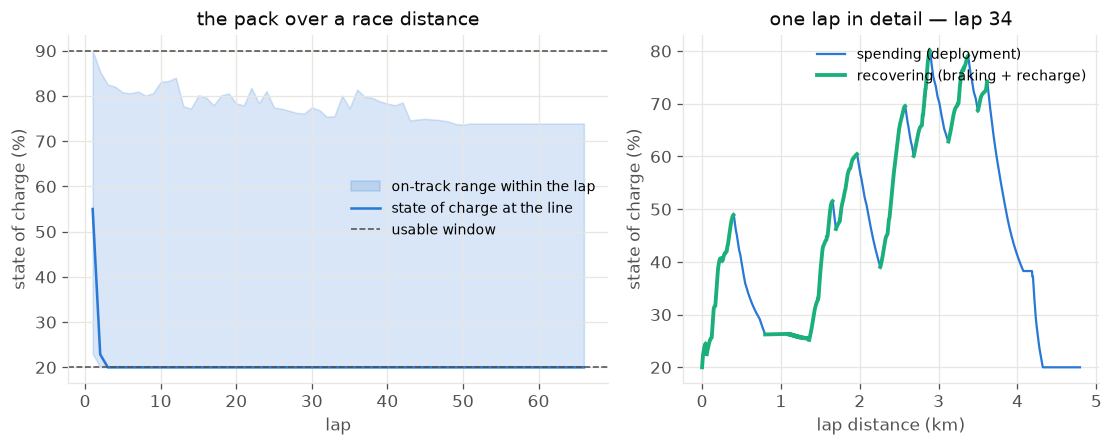

lap 34: on-track swing 3.43 MJ (20.0% … 80.1%), and the pack takes charge over 49% of the lap distance
the store holds 4.00 MJ of usable energy but passes 8.50 MJ through itself on that single lap — 2.1 full charges' worth
lap 1 spends down from the 55% seed: 55.0% at the line → 23.0% at the end of the lap


In [3]:
mid = LAPS // 2                      # a representative mid-race lap (index)
s_km = s_m / 1e3
soc_lo_lap, soc_hi_lap = soc.min(axis=1) * 100, soc.max(axis=1) * 100

fig, (a, b) = plt.subplots(1, 2, figsize=(9.8, 4.0), gridspec_kw={"width_ratios": [1.3, 1]})
a.fill_between(laps, soc_lo_lap, soc_hi_lap, color=BLUE, alpha=0.18,
               label="on-track range within the lap")
a.plot(laps, soc[:, 0] * 100, color=BLUE, lw=1.6, label="state of charge at the line")
a.axhline(SOC_LO * 100, color=INK2, lw=1.0, ls="--")
a.axhline(SOC_HI * 100, color=INK2, lw=1.0, ls="--", label="usable window")
a.set_xlabel("lap")
a.set_ylabel("state of charge (%)")
a.set_title("the pack over a race distance")
a.legend(loc="center right", fontsize=9)

soc_lap = soc[mid] * 100
charging = np.r_[np.diff(soc_lap) > 0.0, False]
b.plot(s_km, soc_lap, color=BLUE, lw=1.4, label="spending (deployment)")
b.plot(s_km, np.where(charging, soc_lap, np.nan), color=AQUA, lw=2.4,
       label="recovering (braking + recharge)")
b.set_xlabel("lap distance (km)")
b.set_ylabel("state of charge (%)")
b.set_title(f"one lap in detail — lap {int(laps[mid])}")
b.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

swing_mj = (soc_hi_lap - soc_lo_lap) / 100.0 * E_PACK_MJ
share_up = float(charging.mean())
print(f"lap {int(laps[mid])}: on-track swing {swing_mj[mid]:.2f} MJ "
      f"({soc_lo_lap[mid]:.1f}% … {soc_hi_lap[mid]:.1f}%), and the pack takes charge over "
      f"{share_up:.0%} of the lap distance")
print(f"the store holds {E_WINDOW_MJ:.2f} MJ of usable energy but passes "
      f"{harvest_mj[mid]:.2f} MJ through itself on that single lap — "
      f"{harvest_mj[mid] / E_WINDOW_MJ:.1f} full charges' worth")
print(f"lap 1 spends down from the 55% seed: {soc[0, 0]:.1%} at the line → "
      f"{soc[0, -1]:.1%} at the end of the lap")

assert 0.2 < share_up < 0.8, "a hybrid lap both spends and recovers over meaningful distance"
assert swing_mj.max() <= E_WINDOW_MJ + 1e-6, "the on-track swing stays inside the usable window"

## 3 · The ledger: what binds

Every lap the solver keeps a ledger of electrical energy **deployed** and **harvested**, and the
manager enforces the regulations against it. Two limits could bind: the deployment curve (a power cap
that tapers away at high speed) or the per-lap harvest allowance. Over a race distance it is the
harvest allowance that binds — the car recovers exactly its allowance every single lap and then
spends what it recovered.

The right-hand panel puts the numbers next to each other: the usable store is small compared with the
energy that flows through it in a lap, which is why the pack is a *buffer*, not a fuel tank.

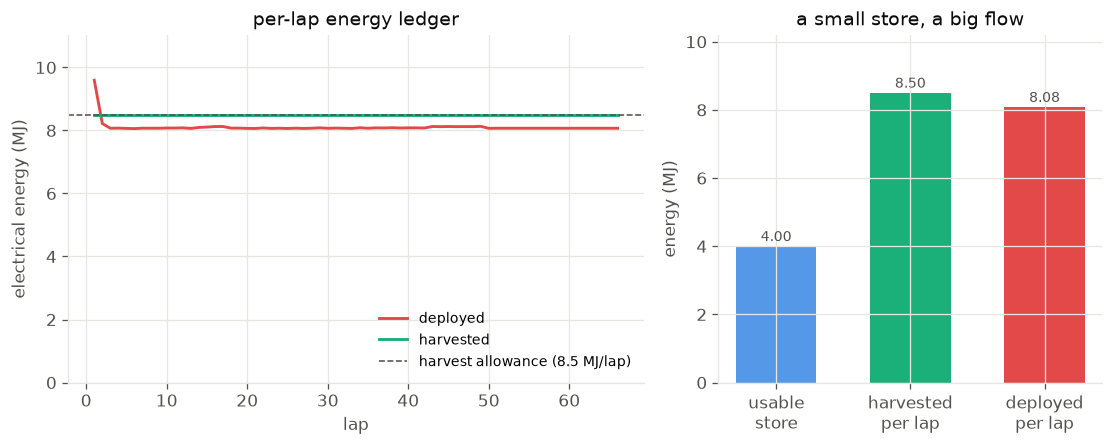

lap 1        deployed 9.59 MJ, harvested 8.50 MJ (net +1.09 MJ — spending the starting charge)
laps 2-66    deployed 8.08 MJ, harvested 8.50 MJ per lap (net -0.42 MJ)
round trip   95.1% of harvested energy comes back out as deployment — the rest is charge/discharge loss
race total   535 MJ deployed / 561 MJ harvested


In [4]:
fig, (a, b) = plt.subplots(1, 2, figsize=(9.8, 4.0), gridspec_kw={"width_ratios": [1.5, 1]})
a.plot(laps, deploy_mj, color=RED, lw=1.8, label="deployed")
a.plot(laps, harvest_mj, color=AQUA, lw=1.8, label="harvested")
a.axhline(HARVEST_BUDGET_MJ, color=INK2, lw=1.0, ls="--",
          label=f"harvest allowance ({HARVEST_BUDGET_MJ:.1f} MJ/lap)")
a.set_xlabel("lap")
a.set_ylabel("electrical energy (MJ)")
a.set_ylim(0.0, max(deploy_mj.max(), HARVEST_BUDGET_MJ) * 1.15)
a.set_title("per-lap energy ledger")
a.legend(loc="lower right", fontsize=9)

names = ["usable\nstore", "harvested\nper lap", "deployed\nper lap"]
vals = [E_WINDOW_MJ, float(harvest_mj[1:].mean()), float(deploy_mj[1:].mean())]
bars = b.bar(names, vals, color=[LOADS5[1], AQUA, RED], width=0.6)
for r, v in zip(bars, vals):
    b.text(r.get_x() + r.get_width() / 2, v + 0.15, f"{v:.2f}", ha="center", fontsize=9,
           color=INK2)
b.set_ylabel("energy (MJ)")
b.set_ylim(0.0, max(vals) * 1.2)
b.set_title("a small store, a big flow")
plt.tight_layout()
plt.show()

steady = slice(1, None)   # lap 1 starts on charge it did not earn
print(f"lap 1        deployed {deploy_mj[0]:.2f} MJ, harvested {harvest_mj[0]:.2f} MJ "
      f"(net {deploy_mj[0] - harvest_mj[0]:+.2f} MJ — spending the starting charge)")
print(f"laps 2-{LAPS}    deployed {deploy_mj[steady].mean():.2f} MJ, harvested "
      f"{harvest_mj[steady].mean():.2f} MJ per lap "
      f"(net {(deploy_mj[steady] - harvest_mj[steady]).mean():+.2f} MJ)")
print(f"round trip   {deploy_mj[steady].mean() / harvest_mj[steady].mean():.1%} of harvested "
      f"energy comes back out as deployment — the rest is charge/discharge loss")
print(f"race total   {deploy_mj.sum():.0f} MJ deployed / {harvest_mj.sum():.0f} MJ harvested")

assert harvest_mj.max() <= HARVEST_BUDGET_MJ + 1e-6, "the harvest allowance is never exceeded"
assert (harvest_mj > 0.9 * HARVEST_BUDGET_MJ).all(), "the allowance binds on every lap"
assert deploy_mj[steady].mean() < harvest_mj[steady].mean(), "a round trip cannot gain energy"

## 4 · Fuel: the car gets lighter, and faster

The engine burns fuel for the traction it covers — the drive force *net* of what the electric machine
is deploying — at the map's brake thermal efficiency. That mass leaves the car, and the centre of
gravity migrates with it, so the whole vehicle description changes slowly over the race. The pace
follows: with the tyres held out of the loop, the lap-time progression below is a clean read on mass
alone.

**And the accounting is honest about a problem.** At this engine map's modelled consumption the
declared race fuel load does not cover 66 laps. The tank runs dry, and the simulator says so: fuel
mass floors at zero (never negative), the car continues at its dry mass, and the pace progression
flattens out because there is no more mass to lose. That flat tail is not a car — it is the model
reporting a fuel budget that does not close. The printout says exactly how much fuel the distance
actually wants, and the tank is physically big enough to hold it — so closing the gap is a loading and
lift-and-coast decision, or a less thirsty engine map, not a bigger fuel cell.

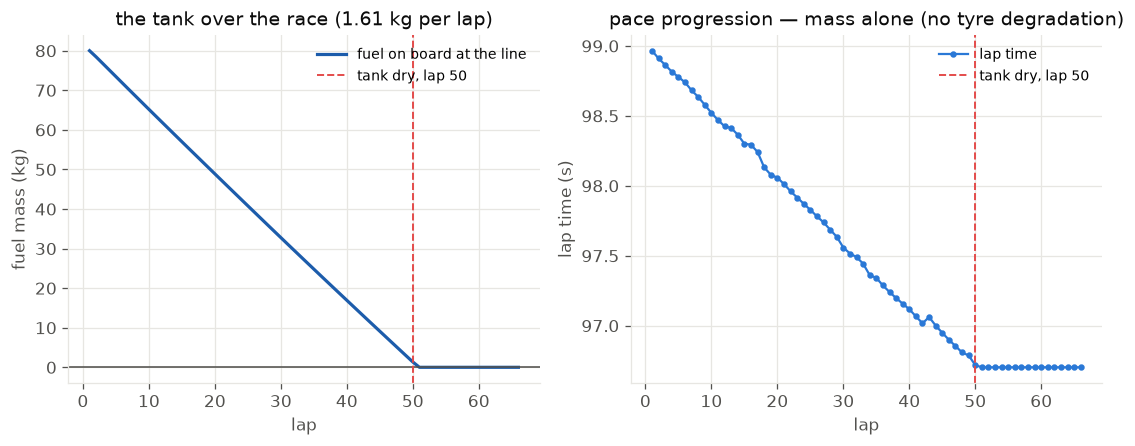

burn rate     1.606 kg/lap over the fuelled phase
pace          98.910 s on lap 2 → 96.787 s on lap 49: 2.12 s for 75.5 kg = 28 ms per kg
fuel budget   the distance wants ≈106 kg; the car declares 80 kg in a 110 kg tank, so it runs dry on lap 50 of 66
engine map    peak brake thermal efficiency ≈40% in this synthetic map, against ≈50% for the real 2026 class — the modelled consumption is on the thirsty side, and this is where that shows up


In [5]:
fuel_lap_start = fuel[:, 0]
burn = -np.diff(np.r_[fuel_lap_start, fuel[-1, -1]])       # kg burned during each lap
ran_dry = bool((fuel[:, -1] <= 0.0).any())
dry = int(np.argmax(fuel[:, -1] <= 0.0)) if ran_dry else LAPS - 1   # first lap that empties it
last_wet = max(1, dry - 1) if ran_dry else LAPS - 1        # last lap run entirely on fuel
fuelled = slice(1, last_wet + 1)                           # the fuelled phase, minus the odd lap 1

fig, (a, b) = plt.subplots(1, 2, figsize=(9.8, 4.0))
a.plot(laps, fuel_lap_start, color=LOADS5[3], lw=2.0, label="fuel on board at the line")
a.axhline(0.0, color=INK2, lw=1.0)
b.plot(laps, lap_time, "o-", color=BLUE, ms=3.0, lw=1.4, label="lap time")
if ran_dry:
    for panel in (a, b):
        panel.axvline(laps[dry], color=RED, lw=1.2, ls="--",
                      label=f"tank dry, lap {int(laps[dry])}")
a.set_xlabel("lap")
a.set_ylabel("fuel mass (kg)")
a.set_title(f"the tank over the race ({burn[fuelled].mean():.2f} kg per lap)")
a.legend(loc="upper right", fontsize=9)

b.set_xlabel("lap")
b.set_ylabel("lap time (s)")
b.set_title("pace progression — mass alone (no tyre degradation)")
b.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

# Pace sensitivity to mass, measured over the fuelled phase.
mass_lost = fuel_lap_start[1] - fuel_lap_start[last_wet]
gain = lap_time[1] - lap_time[last_wet]
need = burn[fuelled].mean() * LAPS
print(f"burn rate     {burn[fuelled].mean():.3f} kg/lap over the fuelled phase")
print(f"pace          {lap_time[1]:.3f} s on lap 2 → {lap_time[last_wet]:.3f} s on lap "
      f"{int(laps[last_wet])}: {gain:.2f} s for {mass_lost:.1f} kg = "
      f"{gain / mass_lost * 1e3:.0f} ms per kg")
print(f"fuel budget   the distance wants ≈{need:.0f} kg; the car declares "
      f"{FUEL_START_KG:.0f} kg in a {TANK_KG:.0f} kg tank, so it runs dry on lap "
      f"{int(laps[dry])} of {LAPS}")
print(f"engine map    peak brake thermal efficiency ≈40% in this synthetic map, against ≈50% for "
      f"the real 2026 class — the modelled consumption is on the thirsty side, and this is where "
      f"that shows up")

assert (np.diff(fuel_lap_start) <= 1e-9).all(), "the tank only ever empties"
assert fuel.min() >= 0.0, "fuel mass floors at zero rather than going negative"
assert lap_time[last_wet] < lap_time[1], "shedding fuel mass makes the car faster"
assert gain / mass_lost * 1e3 > 5.0, "the mass effect on pace is real, not numerical noise"

## 5 · Where the energy moves inside a lap

Zoom into a single lap and the manager's rulebook becomes visible. It has three working modes:

- **Deploy** — the driver is asking for drive, so the machine adds power up to the regulation curve:
  full power to about 290 km/h, then tapering away as the car approaches its terminal speed.
- **Harvest under braking** — the machine takes what the brake demand allows, capped by the pack's
  charge acceptance and by what is left of the lap's allowance.
- **Recharge on throttle** — when the store is below target and the engine has power to spare, the
  machine is back-driven *by the engine* on the straights. This is the phase most people forget: a
  hybrid also charges going forwards, and at full throttle the transition is deliberately
  rate-limited rather than instant.

The lap below is solved on the double-track tier, which resolves the trim (and the energy commands) at
every station along the lap — every 2 m here. Two things are worth staring at. First, the harvest
split in the printout: on this lap **most of the recovered energy is back-driven by the engine, not
recovered from the brakes** — the car is quietly turning fuel into charge on the straights, which is
part of why it drinks. Second, the fine stripes are the rule's own coarseness, not a car oscillating:
the decision is feed-forward and re-taken at every station, so along a straight, where the engine's
spare power hovers around zero, it alternates between deploying and recharging. Every station's energy
still lands in the ledger, so the totals and the race are unaffected — but it is a sampled rule, not a
signal you would send to a real machine. The second figure zooms into one straight and its braking
zone so the phases are resolvable.

two laps solved in 13.8 s (2397 stations each, 2.0 m apart)


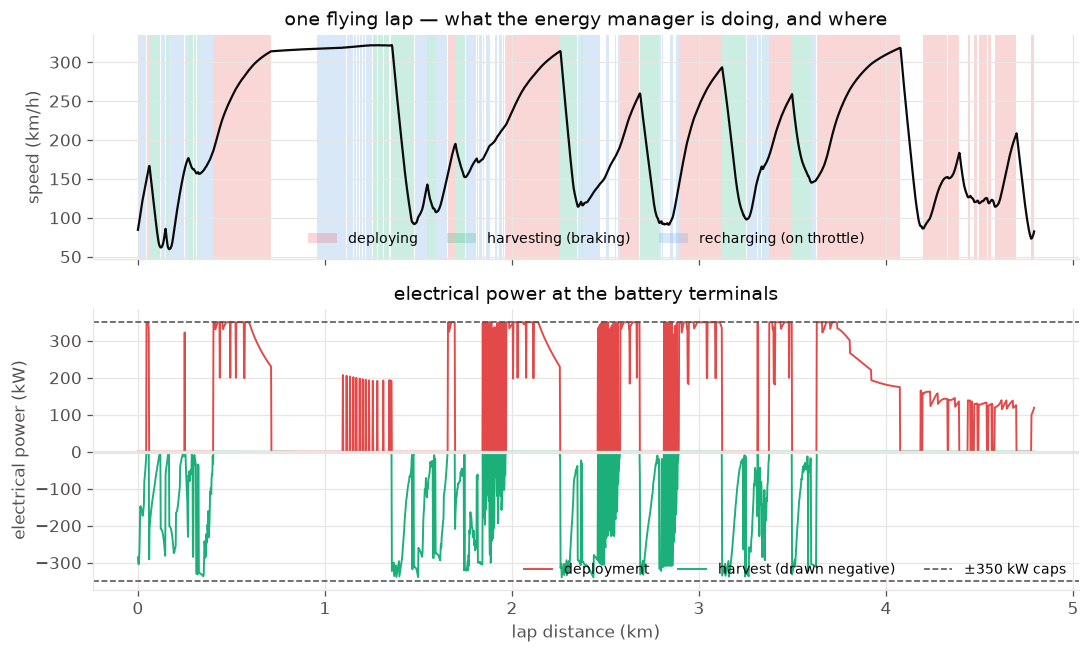

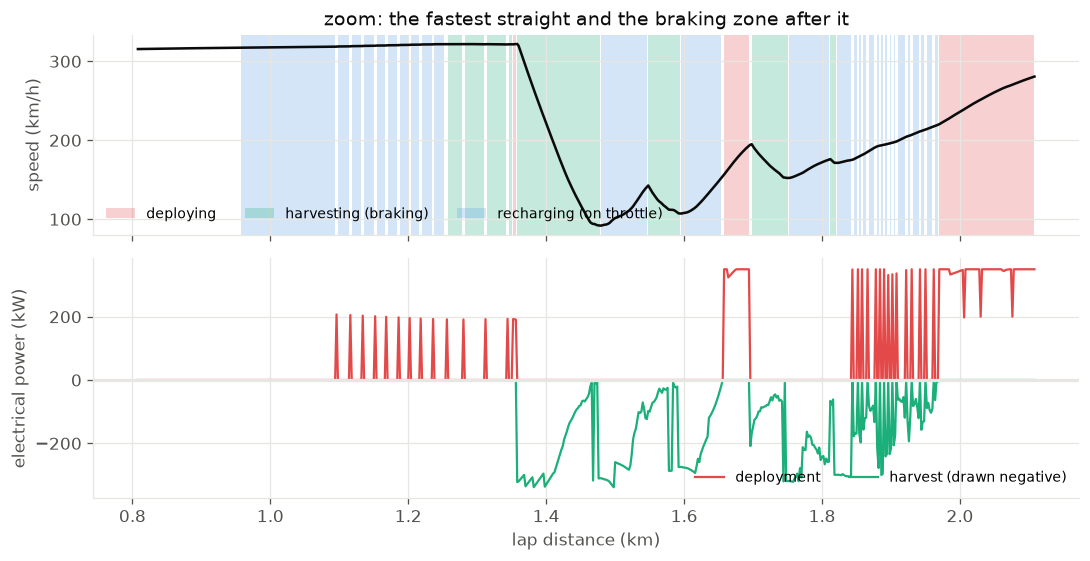

distance share  deploying 44% · braking harvest 19% · on-throttle recharge 26% · coasting/idle 11%
peak power      350 kW out, 340 kW in
harvest split   2.69 MJ from braking, 5.81 MJ back-driven by the engine on throttle
lap time        98.966 s


In [6]:
t0 = time.perf_counter()
plain = solve_lap_dataset(str(F1), raceline, tier="t1", sim=COARSE)
boosted = solve_lap_dataset(str(F1), raceline, tier="t1", sim=COARSE, override=True)
WALL["two flying laps (t1)"] = time.perf_counter() - t0
print(f"two laps solved in {WALL['two flying laps (t1)']:.1f} s "
      f"({len(plain.s)} stations each, {float(plain.s[1] - plain.s[0]):.1f} m apart)")

sl_km = plain.s.values / 1e3
v_kph = plain.v.values * 3.6
dep_kw = plain.deploy_power_w.values / 1e3
har_kw = plain.harvest_power_w.values / 1e3
decel = plain.ax.values < 0.0
m_deploy = dep_kw > 1.0
m_brake = (har_kw > 1.0) & decel
m_recharge = (har_kw > 1.0) & ~decel

fig, (a, b) = plt.subplots(2, 1, figsize=(9.6, 5.8), sharex=True,
                           gridspec_kw={"height_ratios": [1, 1.25]})
for mask, colour, label in ((m_deploy, RED, "deploying"),
                            (m_brake, AQUA, "harvesting (braking)"),
                            (m_recharge, LOADS5[1], "recharging (on throttle)")):
    a.fill_between(sl_km, 0, 1, where=mask, transform=a.get_xaxis_transform(),
                   color=colour, alpha=0.22, lw=0, label=label)
a.plot(sl_km, v_kph, color=INK, lw=1.4)
a.set_ylabel("speed (km/h)")
a.set_title("one flying lap — what the energy manager is doing, and where")
a.legend(loc="lower center", ncols=3, fontsize=9)

b.plot(sl_km, dep_kw, color=RED, lw=1.2, label="deployment")
b.plot(sl_km, -har_kw, color=AQUA, lw=1.2, label="harvest (drawn negative)")
b.axhline(DEPLOY_CAP_KW, color=INK2, lw=1.0, ls="--", label=f"±{DEPLOY_CAP_KW:.0f} kW caps")
b.axhline(-DEPLOY_CAP_KW, color=INK2, lw=1.0, ls="--")
b.axhline(0.0, color=GRID)
b.set_xlabel("lap distance (km)")
b.set_ylabel("electrical power (kW)")
b.set_title("electrical power at the battery terminals")
b.legend(loc="lower right", ncols=3, fontsize=9)
plt.tight_layout()
plt.show()

# The same lap, zoomed onto the fastest straight and the braking zone at the end of it.
i_fast = int(np.argmax(v_kph))
z = (sl_km > sl_km[i_fast] - 0.55) & (sl_km < sl_km[i_fast] + 0.75)
fig, (a, b) = plt.subplots(2, 1, figsize=(9.6, 5.0), sharex=True,
                           gridspec_kw={"height_ratios": [1, 1.2]})
for mask, colour, label in ((m_deploy, RED, "deploying"),
                            (m_brake, AQUA, "harvesting (braking)"),
                            (m_recharge, LOADS5[1], "recharging (on throttle)")):
    a.fill_between(sl_km[z], 0, 1, where=mask[z], transform=a.get_xaxis_transform(),
                   color=colour, alpha=0.25, lw=0, label=label)
a.plot(sl_km[z], v_kph[z], color=INK, lw=1.6)
a.set_ylabel("speed (km/h)")
a.set_title("zoom: the fastest straight and the braking zone after it")
a.legend(loc="lower left", ncols=3, fontsize=9)
b.plot(sl_km[z], dep_kw[z], color=RED, lw=1.4, label="deployment")
b.plot(sl_km[z], -har_kw[z], color=AQUA, lw=1.4, label="harvest (drawn negative)")
b.axhline(0.0, color=GRID)
b.set_xlabel("lap distance (km)")
b.set_ylabel("electrical power (kW)")
b.legend(loc="lower right", ncols=2, fontsize=9)
plt.tight_layout()
plt.show()

t_s = plain.t.values
e_brake = np.trapezoid(np.where(m_brake, har_kw, 0.0), t_s) * 1e-3
e_recharge = np.trapezoid(np.where(m_recharge, har_kw, 0.0), t_s) * 1e-3
print(f"distance share  deploying {m_deploy.mean():.0%} · braking harvest {m_brake.mean():.0%} · "
      f"on-throttle recharge {m_recharge.mean():.0%} · coasting/idle "
      f"{1 - (m_deploy | m_brake | m_recharge).mean():.0%}")
print(f"peak power      {dep_kw.max():.0f} kW out, {har_kw.max():.0f} kW in")
print(f"harvest split   {e_brake:.2f} MJ from braking, {e_recharge:.2f} MJ back-driven by the "
      f"engine on throttle")
print(f"lap time        {plain.attrs['lap_time_s']:.3f} s")

assert not (m_deploy & (har_kw > 1.0)).any(), "the machine never deploys and harvests at once"
assert dep_kw.max() <= DEPLOY_CAP_KW + 1e-6, "deployment respects its power cap"
assert e_brake > 0.0 and e_recharge > 0.0, "both recovery paths are active on a lap"

## 6 · The overtake button, measured

The 2026 rules give the driver an **override** mode: a flatter deployment curve that holds full power
much further up the speed range, plus a small extra harvest allowance for the lap. It is the closest
thing in the regulations to a push-to-pass, so it is worth asking what it is actually worth on one
lap of Catalunya.

The honest answer is: not much, and for an interesting reason. The two deployment curves only differ
above about 290 km/h, and this car spends around 13 seconds a lap up there. The override does deliver
more energy in exactly that window — but the pack, not the curve, is what limits the rest of the lap,
so deploying harder on the straight leaves slightly less to spend elsewhere. The lap gain is
measurable and small. Where the override *does* move a real number is the harvest allowance, which is
half a megajoule larger.

The left panel is also a good look at why a regulation curve is not a promise. The realised points fan
out *below* both curves at low and middling speed, in gear-shaped arcs: the machine is bolted to the
same crank as the engine, so it deploys in whatever gear the car is in, and in the lower gears its own
torque envelope — not the rule — is what limits it.

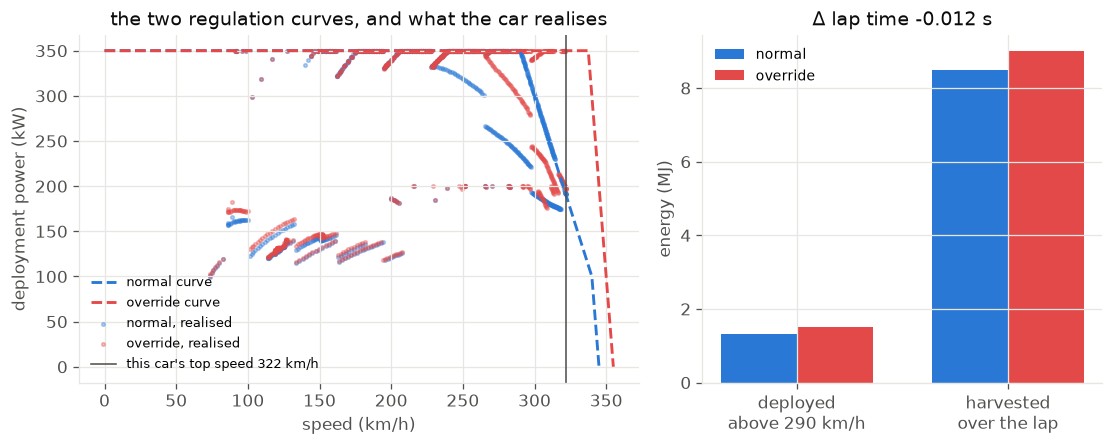

lap time      98.966 s normal → 98.954 s with override (-0.012 s)
high speed    1.321 → 1.506 MJ deployed above 290 km/h (+0.185 MJ, where the curves differ)
whole lap     9.615 → 9.451 MJ deployed: spending more on the straight leaves less for the rest of the lap
harvest       8.495 → 8.994 MJ allowed back in (+0.499 MJ, the override bonus)
time above 290 km/h: 12.9 s of the lap


In [7]:
fast = v_kph > 290.0
vb_kph = boosted.v.values * 3.6
depb_kw = boosted.deploy_power_w.values / 1e3
e_fast = np.trapezoid(np.where(fast, dep_kw, 0.0), t_s) * 1e-3
e_fast_b = np.trapezoid(np.where(vb_kph > 290.0, depb_kw, 0.0), boosted.t.values) * 1e-3
h_plain = np.trapezoid(har_kw, t_s) * 1e-3
h_boost = np.trapezoid(boosted.harvest_power_w.values / 1e3, boosted.t.values) * 1e-3

fig, (a, b) = plt.subplots(1, 2, figsize=(9.8, 4.0), gridspec_kw={"width_ratios": [1.4, 1]})
for mode, colour, pol in (("normal", BLUE, spec["policy"]["deployment"]),
                          ("override", RED, spec["policy"]["override_mode"])):
    curve_v = np.asarray(pol["taper_vs_speed"]["speed_kph"], float)
    curve_p = np.asarray(pol["taper_vs_speed"]["power_frac"], float) * pol["power_limit_kw"]
    a.plot(curve_v, curve_p, color=colour, lw=1.8, ls="--", label=f"{mode} curve")
a.scatter(v_kph[m_deploy], dep_kw[m_deploy], s=5, alpha=0.35, color=BLUE, label="normal, realised")
a.scatter(vb_kph[depb_kw > 1.0], depb_kw[depb_kw > 1.0], s=5, alpha=0.35, color=RED,
          label="override, realised")
a.axvline(v_kph.max(), color=INK2, lw=1.0, label=f"this car's top speed {v_kph.max():.0f} km/h")
a.set_xlabel("speed (km/h)")
a.set_ylabel("deployment power (kW)")
a.set_title("the two regulation curves, and what the car realises")
a.legend(loc="lower left", fontsize=8)

x = np.arange(2)
w = 0.36
b.bar(x - w / 2, [e_fast, h_plain], width=w, color=BLUE, label="normal")
b.bar(x + w / 2, [e_fast_b, h_boost], width=w, color=RED, label="override")
b.set_xticks(x, ["deployed\nabove 290 km/h", "harvested\nover the lap"])
b.set_ylabel("energy (MJ)")
b.set_title(f"Δ lap time {boosted.attrs['lap_time_s'] - plain.attrs['lap_time_s']:+.3f} s")
b.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

print(f"lap time      {plain.attrs['lap_time_s']:.3f} s normal → "
      f"{boosted.attrs['lap_time_s']:.3f} s with override "
      f"({boosted.attrs['lap_time_s'] - plain.attrs['lap_time_s']:+.3f} s)")
print(f"high speed    {e_fast:.3f} → {e_fast_b:.3f} MJ deployed above 290 km/h "
      f"({e_fast_b - e_fast:+.3f} MJ, where the curves differ)")
print(f"whole lap     {np.trapezoid(dep_kw, t_s) * 1e-3:.3f} → "
      f"{np.trapezoid(depb_kw, boosted.t.values) * 1e-3:.3f} MJ deployed: spending more on the "
      f"straight leaves less for the rest of the lap")
print(f"harvest       {h_plain:.3f} → {h_boost:.3f} MJ allowed back in "
      f"({h_boost - h_plain:+.3f} MJ, the override bonus)")
print(f"time above 290 km/h: {np.trapezoid(fast.astype(float), t_s):.1f} s of the lap")

assert e_fast_b > e_fast, "override deploys more where the curves differ"
assert h_boost > h_plain, "override carries a larger harvest allowance"
assert boosted.attrs["lap_time_s"] <= plain.attrs["lap_time_s"], "override is not slower"
assert abs(boosted.attrs["lap_time_s"] - plain.attrs["lap_time_s"]) < 0.5, "…but not a magic button"

## 7 · The same energy manager, in the time domain

Everything above rides the quasi-steady tier: a velocity profile with the slow states marched along
it. The transient tier is a different animal — a driver model steering and braking a car through time,
integrated at a millisecond step, with the same energy manager deciding what the machine does at every
step.

Running a short stint on it is a cross-check of the *energy* story, and only of that. The two tiers do
not produce the same lap time here, and the gap is not small: the transient driver drives to a
deliberate stability margin — it deliberately leaves grip in hand rather than riding the exact edge of
the envelope — and on this tight minimum-curvature line that costs it around sixteen percent. That is
a property of the driver model and its margin setting, recorded rather than papered over, not a
statement about the car. (Pace parity between the tiers is checked elsewhere, on lines and vehicles
where the driver is not the limiting factor.)

What should agree, and does, is what the regulations make binding: the harvest allowance is exhausted
in both tiers, the pack rides the same usable window in both, and the deployed energy tracks the pace
difference rather than diverging from it.

2-lap transient stint in 9.6 s (fixed step 1 ms, speed margin 0.85)


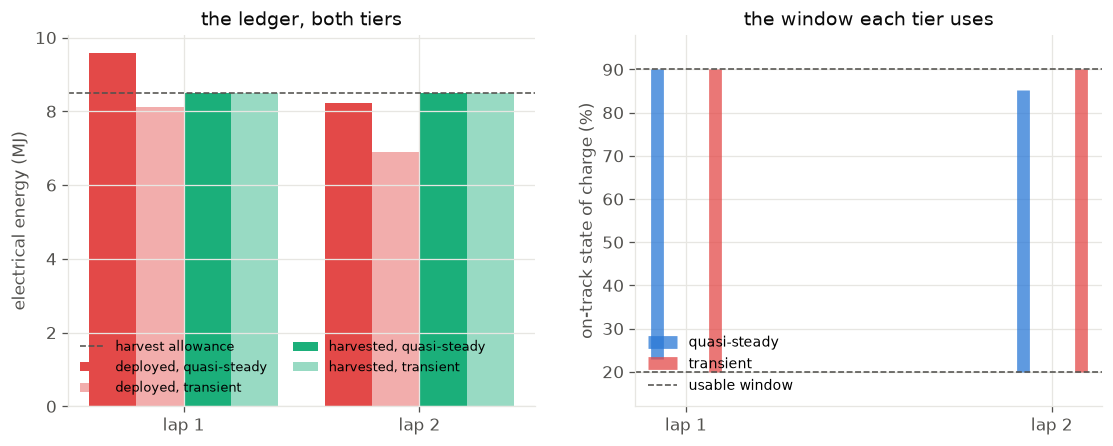

harvested per lap  quasi-steady [8.5 8.5] MJ · transient [8.5 8.5] MJ — the allowance binds in both
deployed per lap   quasi-steady [9.59 8.22] MJ · transient [8.12 6.89] MJ
lap time           quasi-steady 98.97 s · transient 114.92 s (+16.1% — the driver model's stability margin, recorded, not a car difference)


In [8]:
t0 = time.perf_counter()
tran = solve_stint_dataset(
    str(F1), raceline, n_laps=2, tier="t2", sim=COARSE, tire_thermal=False
)
WALL["short transient stint (t2)"] = time.perf_counter() - t0
print(f"{tran.attrs['n_laps']}-lap transient stint in {WALL['short transient stint (t2)']:.1f} s "
      f"(fixed step {float(tran.attrs['dt_s']) * 1e3:.0f} ms, "
      f"speed margin {float(tran.attrs['speed_margin']):.2f})")

n = int(tran.attrs["n_laps"])
x = np.arange(1, n + 1)
w = 0.2
fig, (a, b) = plt.subplots(1, 2, figsize=(9.8, 4.0))
a.bar(x - 1.5 * w, deploy_mj[:n], width=w, color=RED, label="deployed, quasi-steady")
a.bar(x - 0.5 * w, tran.deploy_energy_mj.values, width=w, color=RED, alpha=0.45,
      label="deployed, transient")
a.bar(x + 0.5 * w, harvest_mj[:n], width=w, color=AQUA, label="harvested, quasi-steady")
a.bar(x + 1.5 * w, tran.harvest_energy_mj.values, width=w, color=AQUA, alpha=0.45,
      label="harvested, transient")
a.axhline(HARVEST_BUDGET_MJ, color=INK2, lw=1.0, ls="--", label="harvest allowance")
a.set_xticks(x, [f"lap {i}" for i in x])
a.set_ylabel("electrical energy (MJ)")
a.set_title("the ledger, both tiers")
a.legend(loc="lower left", fontsize=8, ncols=2)

for i, (lo, hi, colour, label) in enumerate((
    (soc[:n].min(axis=1), soc[:n].max(axis=1), BLUE, "quasi-steady"),
    (tran.soc_min.values, tran.soc_max.values, RED, "transient"),
)):
    off = (i - 0.5) * 0.16
    b.vlines(x + off, lo * 100, hi * 100, color=colour, lw=8, alpha=0.75, label=label)
b.axhline(SOC_LO * 100, color=INK2, lw=1.0, ls="--")
b.axhline(SOC_HI * 100, color=INK2, lw=1.0, ls="--", label="usable window")
b.set_xticks(x, [f"lap {i}" for i in x])
b.set_ylabel("on-track state of charge (%)")
b.set_ylim(SOC_LO * 100 - 8, SOC_HI * 100 + 8)
b.set_title("the window each tier uses")
b.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()

print(f"harvested per lap  quasi-steady {harvest_mj[:n]} MJ · transient "
      f"{np.round(tran.harvest_energy_mj.values, 3)} MJ — the allowance binds in both")
print(f"deployed per lap   quasi-steady {np.round(deploy_mj[:n], 2)} MJ · transient "
      f"{np.round(tran.deploy_energy_mj.values, 2)} MJ")
print(f"lap time           quasi-steady {lap_time[0]:.2f} s · transient "
      f"{float(tran.lap_time_s.values[0]):.2f} s "
      f"({(tran.lap_time_s.values[0] / lap_time[0] - 1) * 100:+.1f}% — the driver model's "
      f"stability margin, recorded, not a car difference)")

assert bool(int(tran.attrs["completed"])), "the transient stint completed both laps"
assert (tran.harvest_energy_mj.values > 0.9 * HARVEST_BUDGET_MJ).all(), "allowance binds in T2 too"
assert tran.harvest_energy_mj.values.max() <= HARVEST_BUDGET_MJ + 1e-6, "and is never exceeded"
assert tran.soc_min.values.min() >= SOC_LO - 1e-9, "the pack window holds in the transient tier"
assert tran.soc_max.values.max() <= SOC_HI + 1e-9

## 8 · Pitch under braking, and what it does to the balance

One more tier, one more degree of honesty. The 14-DOF tier gives the sprung mass its own heave, pitch
and roll, four unsprung masses, and — the reason it exists — **aerodynamics evaluated at the
instantaneous ride heights** rather than at a steady platform. The car's downforce map is indexed on
front and rear ride height, so when the platform moves, the aerodynamic balance moves with it.

Below is the biggest braking event of a lap, and the sequence is worth following carefully because it
is not the one most people expect.

At the end of the straight the car is doing about 280 km/h and downforce has **squashed the platform
almost onto the road** — a couple of millimetres of front ride height, tens of millimetres below its
static setting. Then the driver brakes. Deceleration pitches the sprung mass nose-down, but speed is
falling at the same time, so downforce is bleeding away and both ends of the car are *rising* back
toward static. The two effects compete, and the front loses: it comes back up more slowly than the
rear, which is what nose-down pitch means. The downforce map, which is indexed on the two ride
heights, answers by moving the balance **forwards** — about two percentage points of downforce shifted
onto the front axle, peaking a second into the braking event, exactly while the driver is asking the
front axle for turn-in grip, and relaxing away again as the car settles for the corner.

That is the mechanism behind a familiar setup complaint ("it bites on entry if I brake later"), and it
only exists in a tier where the suspension is a live state rather than an equilibrium.

Two honesty notes on the bottom panel. The balance is read back from the same tabulated map the solver
rides (at zero yaw, movable element closed), linearly between its nodes — the solver uses its own
smooth interpolation, so treat the trace as an illustration of the map's shape rather than the exact
number in the loop. And at these speeds the front platform sits **below the lowest ride height the map
tabulates** (10 mm), where the read-back clamps to the edge node: that is the flat start of the trace,
and it means the shift drawn here is a lower bound. A map that only goes down to 10 mm is under-covering
this car's actual operating range — the kind of gap worth fixing in the data, not in the plot.

14-DOF lap in 1.8 s: 103.63 s, 103634 steps


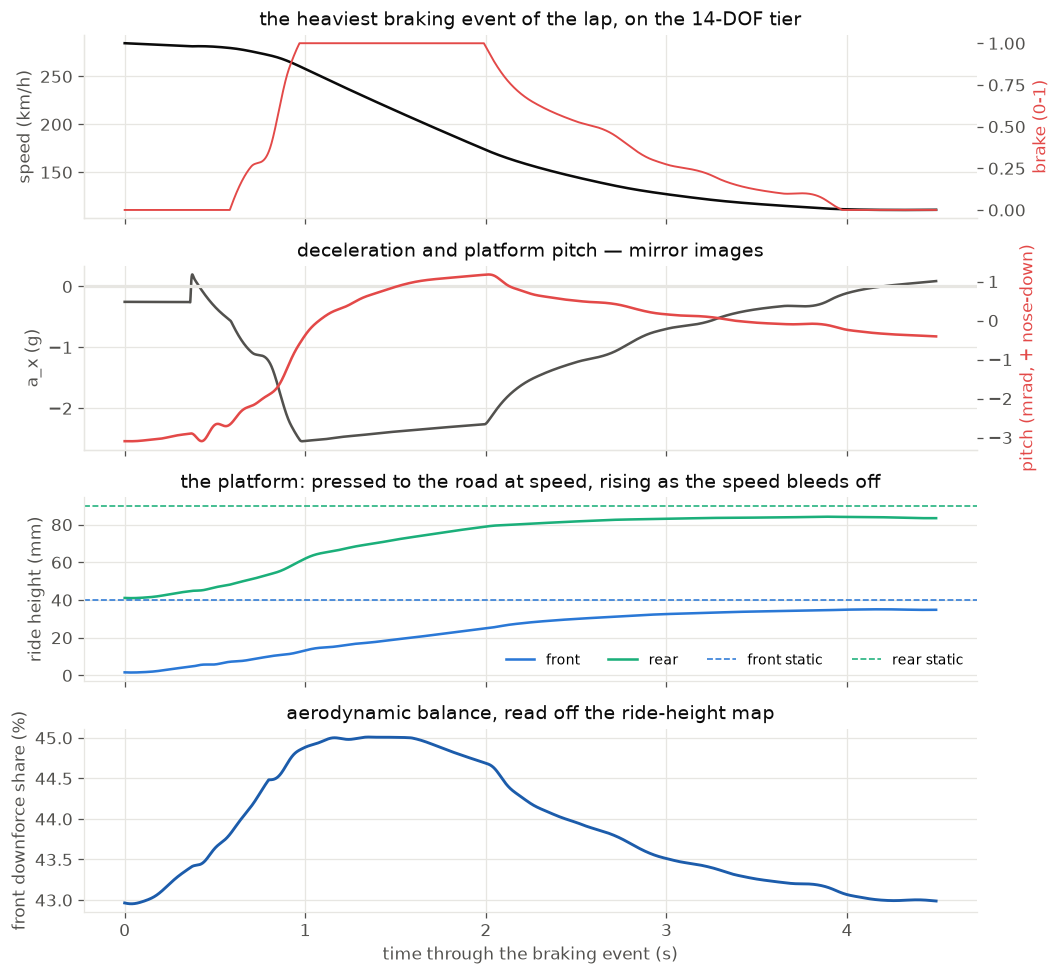

event         3.29 s on the brakes, 279 → 112 km/h, peak -2.54 g
platform      at brake application front 7.4 mm / rear 48.6 mm; at peak deceleration front 12.8 mm / rear 61.2 mm; static 40/90 mm
              (downforce is bleeding away as the car slows, so both ends rise — the front just rises more slowly)
pitch         -3.09 mrad (squat, on power) → +1.18 mrad (nose-down, on the brakes); correlation with a_x over the whole lap -0.73
balance       43.0% front at speed → 45.0% at its peak (+2.0 points forward), back to 43.0% as the car settles
map coverage  the front platform spends 9% of the lap below the map's lowest tabulated ride height (10 mm)
lap time      103.63 s on this tier


In [9]:
t0 = time.perf_counter()
ride = solve_lap_dataset(str(F1), raceline, ds_m=8.0, tier="t3", sim=COARSE)
WALL["one 14-DOF lap (t3)"] = time.perf_counter() - t0
print(f"14-DOF lap in {WALL['one 14-DOF lap (t3)']:.1f} s: "
      f"{ride.attrs['lap_time_s']:.2f} s, {len(ride.time)} steps")

# Front downforce share, read back from the car's tabulated aero map (yaw = 0, element closed).
tab = pq.read_table(F1 / spec["aero"]["map"])
col = {name: np.asarray(tab.column(name)) for name in tab.schema.names}
plane = (col["yaw_deg"] == 0.0) & (col["drs_flag"] == 0.0)
HF = np.unique(col["ride_height_f_mm"][plane])
HR = np.unique(col["ride_height_r_mm"][plane])
SHARE = np.empty((HF.size, HR.size))
for i, hf_node in enumerate(HF):
    for j, hr_node in enumerate(HR):
        k = plane & (col["ride_height_f_mm"] == hf_node) & (col["ride_height_r_mm"] == hr_node)
        cz_f, cz_r = col["cz_front_a_m2"][k][0], col["cz_rear_a_m2"][k][0]
        SHARE[i, j] = cz_f / (cz_f + cz_r)


def front_share(hf_mm, hr_mm):
    """Front share of total downforce, bilinear between the map's tabulated nodes."""
    hf_q, hr_q = np.atleast_1d(hf_mm), np.atleast_1d(hr_mm)
    per_rear = np.stack([np.interp(hf_q, HF, SHARE[:, j]) for j in range(HR.size)])
    return np.array([np.interp(hr_q[k], HR, per_rear[:, k]) for k in range(hf_q.size)])


t_r = ride.time.values
ax_g = ride.ax.values / 9.81
brake = ride.brake.values
hf_mm, hr_mm = ride.ride_height_f_m.values * 1e3, ride.ride_height_r_m.values * 1e3
pitch_mrad = ride.pitch_rad.values * 1e3

peak = int(np.argmin(ride.ax.values))          # the heaviest braking instant of the lap
on = brake > 0.05
lo, hi = peak, peak
while lo > 0 and on[lo - 1]:
    lo -= 1
while hi < on.size - 1 and on[hi + 1]:
    hi += 1
win = slice(max(0, lo - 600), min(on.size, hi + 600))       # the event plus 0.6 s either side
tw = t_r[win] - t_r[win][0]
share_pct = front_share(hf_mm[win], hr_mm[win]) * 100.0

fig, axs = plt.subplots(4, 1, figsize=(9.2, 8.6), sharex=True)
axs[0].plot(tw, ride.vx.values[win] * 3.6, color=INK, lw=1.6, label="speed")
axs[0].set_ylabel("speed (km/h)")
axs[0].set_title("the heaviest braking event of the lap, on the 14-DOF tier")
brk_ax = axs[0].twinx()
brk_ax.plot(tw, brake[win], color=RED, lw=1.2, label="brake")
brk_ax.set_ylabel("brake (0-1)", color=RED)
brk_ax.grid(False)

axs[1].plot(tw, ax_g[win], color=INK2, lw=1.6)
axs[1].axhline(0.0, color=GRID)
axs[1].set_ylabel("a_x (g)")
p_ax = axs[1].twinx()
p_ax.plot(tw, pitch_mrad[win], color=RED, lw=1.6)
p_ax.set_ylabel("pitch (mrad, + nose-down)", color=RED)
p_ax.grid(False)
axs[1].set_title("deceleration and platform pitch — mirror images")

axs[2].plot(tw, hf_mm[win], color=BLUE, lw=1.6, label="front")
axs[2].plot(tw, hr_mm[win], color=AQUA, lw=1.6, label="rear")
axs[2].axhline(H_STATIC_F_MM, color=BLUE, lw=1.0, ls="--", label="front static")
axs[2].axhline(H_STATIC_R_MM, color=AQUA, lw=1.0, ls="--", label="rear static")
axs[2].set_ylabel("ride height (mm)")
axs[2].set_title("the platform: pressed to the road at speed, rising as the speed bleeds off")
axs[2].legend(ncols=4, fontsize=9, loc="lower right")

axs[3].plot(tw, share_pct, color=LOADS5[3], lw=1.8)
axs[3].set_xlabel("time through the braking event (s)")
axs[3].set_ylabel("front downforce share (%)")
axs[3].set_title("aerodynamic balance, read off the ride-height map")
plt.tight_layout()
plt.show()

strong = np.abs(ride.ax.values) > 3.0
corr = float(np.corrcoef(ride.ax.values[strong], ride.pitch_rad.values[strong])[0, 1])
print(f"event         {t_r[hi] - t_r[lo]:.2f} s on the brakes, "
      f"{ride.vx.values[lo] * 3.6:.0f} → {ride.vx.values[hi] * 3.6:.0f} km/h, peak "
      f"{ax_g[peak]:.2f} g")
print(f"platform      at brake application front {hf_mm[lo]:.1f} mm / rear {hr_mm[lo]:.1f} mm; "
      f"at peak deceleration front {hf_mm[peak]:.1f} mm / rear {hr_mm[peak]:.1f} mm; "
      f"static {H_STATIC_F_MM:.0f}/{H_STATIC_R_MM:.0f} mm")
print(f"              (downforce is bleeding away as the car slows, so both ends rise — the front "
      f"just rises more slowly)")
print(f"pitch         {pitch_mrad[win].min():+.2f} mrad (squat, on power) → "
      f"{pitch_mrad[win].max():+.2f} mrad (nose-down, on the brakes); correlation with a_x over "
      f"the whole lap {corr:+.2f}")
print(f"balance       {share_pct[0]:.1f}% front at speed → {share_pct.max():.1f}% at its peak "
      f"({share_pct.max() - share_pct[0]:+.1f} points forward), back to {share_pct[-1]:.1f}% as "
      f"the car settles")
print(f"map coverage  the front platform spends {(hf_mm < HF.min()).mean():.0%} of the lap below "
      f"the map's lowest tabulated ride height ({HF.min():.0f} mm)")
print(f"lap time      {ride.attrs['lap_time_s']:.2f} s on this tier")

assert bool(int(ride.attrs["completed"])), "the 14-DOF lap completed"
assert corr < -0.3, "the platform pitches nose-down under braking"
assert hf_mm.mean() < H_STATIC_F_MM and hr_mm.mean() < H_STATIC_R_MM, "downforce sinks the platform"
assert share_pct.max() > share_pct[0], "diving the front moves the balance forward"

In [10]:
total = sum(WALL.values())
print("solver wall clock on this machine")
for stage, seconds in WALL.items():
    print(f"  {stage:26s} {seconds:7.1f} s")
print(f"  {'TOTAL solver time':26s} {total:7.1f} s")
print(f"  {'whole notebook':26s} {time.perf_counter() - t_notebook:7.1f} s")

# The notebook is executed in CI with a per-cell timeout; the race is the binding cell by far.
assert max(WALL.values()) < 900.0, "every stage must fit the per-cell execution budget"

solver wall clock on this machine
  the 66-lap race              136.4 s
  two flying laps (t1)          13.8 s
  short transient stint (t2)     9.6 s
  one 14-DOF lap (t3)            1.8 s
  TOTAL solver time            161.7 s
  whole notebook               164.5 s


---

## What this walkthrough showed

- A **full race distance** of coupled energy accounting: 66 laps carrying the battery, its
  temperatures, the machine's winding temperature and the fuel load across every start/finish line,
  with only the per-lap regulatory ledger resetting.
- **Charge moves both ways.** The pack drains under deployment and refills under braking *and* under
  engine back-drive on the straights, roughly half the lap distance putting energy back in. The store
  is small enough that the whole race passes through it more than a hundred times.
- **The binding limit is the per-lap harvest allowance**, not the deployment curve and not the pack:
  the car recovers exactly its allowance every lap, and then spends slightly less than that — the
  round-trip loss, visible in the ledger.
- **Fuel is the other half of the pace story.** Shedding mass is worth tens of milliseconds a
  kilogram, and the model is candid where the budget fails to close: at this engine map's efficiency
  the declared race load does not cover the distance, and the trace floors at an empty tank instead of
  inventing fuel.
- **The overtake mode is worth what it is worth** — more energy where the curves differ, a larger
  harvest allowance, and a lap gain small enough that it has to be measured rather than assumed.
- **The tiers agree on what the rules make binding.** The transient tier exhausts the same allowance
  and rides the same pack window, at its own pace; and the 14-DOF tier adds a platform that pitches
  under braking and moves the aerodynamic balance forward with it.

**Where to go next:** [10 · stint strategy](10_stint_strategy.ipynb) is the other half of race pace —
tyre warm-up, wear and the grip cliff, on the same car and track, which is exactly what this notebook
held still. [09 · race engineering](09_race_engineering.ipynb) reads traces the way an engineer does,
and [07 · the full quasi-steady tier](07_qss_t1.ipynb) is where the per-wheel trim and the g-g-g-v
envelope underneath all of this are unpacked.